In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/arsenal.csv")
df

,name,position,height_cm,weight_kg,age,foot,pace,passing,defending,finishing,aerial_duels,tackling
0,David Raya,GK,190,82,29,R,48,62,30,25,86,32
1,Aaron Ramsdale,GK,188,83,26,R,50,60,32,28,84,34
2,William Saliba,DEF,192,92,23,R,78,71,89,38,88,88
3,Gabriel Magalhaes,DEF,190,86,26,L,72,67,87,42,86,86
4,Ben White,DEF,185,78,26,R,75,72,82,35,80,82
5,Takehiro Tomiyasu,DEF,188,84,26,R,70,66,84,33,83,85
6,Oleksandr Zinchenko,DEF,175,70,27,L,74,80,76,40,70,72
7,Jurrien Timber,DEF,179,78,23,R,78,70,83,36,78,84
8,Jakub Kiwior,DEF,189,80,24,L,73,66,81,34,79,80
9,Declan Rice,MID,185,82,25,R,73,80,75,58,74,74


In [76]:
df.head()

,name,position,height_cm,weight_kg,age,foot,pace,passing,defending,finishing,aerial_duels,tackling
0,David Raya,GK,190,82,29,R,48,62,30,25,86,32
1,Aaron Ramsdale,GK,188,83,26,R,50,60,32,28,84,34
2,William Saliba,DEF,192,92,23,R,78,71,89,38,88,88
3,Gabriel Magalhaes,DEF,190,86,26,L,72,67,87,42,86,86
4,Ben White,DEF,185,78,26,R,75,72,82,35,80,82


In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
height_cm,20.0,181.80,6.550211,170.0,177.25,181.0,188.00,192.0
weight_kg,20.0,76.65,7.191186,64.0,71.50,76.5,82.00,92.0
age,20.0,25.70,2.536056,22.0,23.75,25.5,27.00,31.0
pace,20.0,73.95,11.137774,48.0,71.50,74.0,79.50,89.0
passing,20.0,73.90,8.103930,60.0,67.75,73.5,79.25,90.0
defending,20.0,61.90,19.547244,30.0,44.75,59.0,81.25,89.0
finishing,20.0,53.75,20.667480,25.0,35.75,52.5,67.50,86.0
aerial_duels,20.0,70.65,11.672167,55.0,59.50,71.5,80.75,88.0
tackling,20.0,61.65,19.156626,32.0,44.25,59.0,80.50,88.0


In [78]:
X, y = df.drop(["position", "foot", "age", "name"], axis=1), df["position"]
X

,height_cm,weight_kg,pace,passing,defending,finishing,aerial_duels,tackling
0,190,82,48,62,30,25,86,32
1,188,83,50,60,32,28,84,34
2,192,92,78,71,89,38,88,88
3,190,86,72,67,87,42,86,86
4,185,78,75,72,82,35,80,82
5,188,84,70,66,84,33,83,85
6,175,70,74,80,76,40,70,72
7,179,78,78,70,83,36,78,84
8,189,80,73,66,81,34,79,80
9,185,82,73,80,75,58,74,74


In [79]:
y

0      GK
1      GK
2     DEF
3     DEF
4     DEF
5     DEF
6     DEF
7     DEF
8     DEF
9     MID
10    MID
11    MID
12    MID
13    MID
14    MID
15    FWD
16    FWD
17    FWD
18    FWD
19    FWD
Name: position, dtype: object

In [80]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [90]:



X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)

scaler_standard = StandardScaler()

scaled_X_train_std = scaler_standard.fit_transform(X_train)
scaled_X_test_std = scaler_standard.transform(X_test)

model_std = LogisticRegression(penalty=None, max_iter=1000)
model_std.fit(scaled_X_train_std, y_train)
y_pred_std = model_std.predict(scaled_X_test_std)
acc_std = accuracy_score(y_test, y_pred_std)


scaler_minmax = MinMaxScaler()

scaled_X_train_mm = scaler_minmax.fit_transform(X_train)
scaled_X_test_mm = scaler_minmax.transform(X_test)

model_mm = LogisticRegression(penalty=None, max_iter=1000)
model_mm.fit(scaled_X_train_mm, y_train)
y_pred_mm = model_mm.predict(scaled_X_test_mm)
acc_mm = accuracy_score(y_test, y_pred_mm )

print("Accuracy (StandardScaler): ", acc_std)
print("Accuracy (MinMaxScaler): ", acc_mm)

train_cols = list(X.columns)


Accuracy (StandardScaler):  0.7142857142857143
Accuracy (MinMaxScaler):  0.7142857142857143


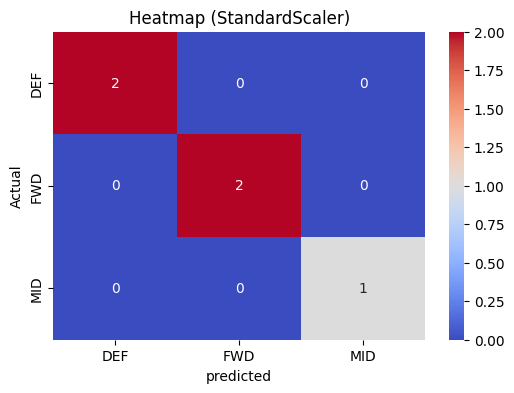

In [82]:
cm_std = confusion_matrix(y_test, y_pred_std, labels=model_mm.classes_) 
cm_mm = confusion_matrix(y_test, y_pred_mm, labels=model_mm.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm_std, annot=True,cmap="coolwarm", xticklabels=model_std.classes_, yticklabels=model_std.classes_)

plt.title("Heatmap (StandardScaler)")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()


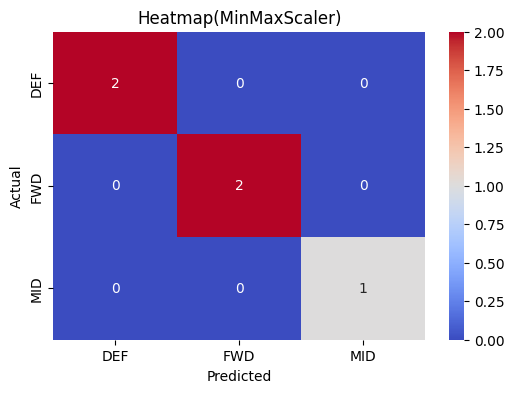

In [83]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_mm, annot=True, cmap="coolwarm", xticklabels=model_mm.classes_, yticklabels=model_mm.classes_)

plt.title("Heatmap(MinMaxScaler)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [84]:
df_test = pd.read_csv("../data/synthetic_players_100.csv")
df_test.head()

X_new, y_new = df_test.drop("position", axis=1), df_test["position"]

X_new


,height_cm,weight_kg,pace,passing,defending,finishing,aerial_duels,tackling
0,188,73,68,61,82,39,85,83
1,180,75,72,82,58,55,61,69
2,175,75,83,80,50,87,70,59
3,180,81,79,77,84,53,77,87
4,181,71,77,82,63,56,56,57
...,...,...,...,...,...,...,...,...
95,180,77,68,71,70,52,76,71
96,173,75,86,84,55,87,69,53
97,187,79,78,68,91,46,88,82
98,180,73,84,61,49,86,58,51


In [85]:
X_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   height_cm     100 non-null    int64
 1   weight_kg     100 non-null    int64
 2   pace          100 non-null    int64
 3   passing       100 non-null    int64
 4   defending     100 non-null    int64
 5   finishing     100 non-null    int64
 6   aerial_duels  100 non-null    int64
 7   tackling      100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [86]:
y_new.info()

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: position
Non-Null Count  Dtype 
--------------  ----- 
100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [ ]:

X_new.head()

,height_cm,weight_kg,pace,passing,defending,finishing,aerial_duels,tackling
0,188,73,68,61,82,39,85,83
1,180,75,72,82,58,55,61,69
2,175,75,83,80,50,87,70,59
3,180,81,79,77,84,53,77,87
4,181,71,77,82,63,56,56,57


In [89]:
X.head()

,height_cm,weight_kg,pace,passing,defending,finishing,aerial_duels,tackling
0,190,82,48,62,30,25,86,32
1,188,83,50,60,32,28,84,34
2,192,92,78,71,89,38,88,88
3,190,86,72,67,87,42,86,86
4,185,78,75,72,82,35,80,82


In [ ]:
try:
    train_cols
except NameError:
    train_cols = list(X.columns)

In [91]:
X_new_std = scaler_standard.transform(X_new)
y_pred_std_new = model_std.predict(X_new_std)
print("\n=== StandardScaler på ny CSV ===")
print("Accuracy:", accuracy_score(y_new, y_pred_std_new))
print(classification_report(y_new, y_pred_std_new))
print("Confusion matrix:\n", confusion_matrix(y_new, y_pred_std_new, labels=model_std.classes_))
print("Class order:", model_std.classes_)

X_new_mm = scaler_minmax.transform(X_new)     # OBS: transform, INTE fit_transform
y_pred_mm_new = model_mm.predict(X_new_mm)

print("\n=== MinMaxScaler på ny CSV ===")
print("Accuracy:", accuracy_score(y_new, y_pred_mm_new))
print(classification_report(y_new, y_pred_mm_new))
print("Confusion matrix:\n", confusion_matrix(y_new, y_pred_mm_new, labels=model_mm.classes_))
print("Class order:", model_mm.classes_)


=== StandardScaler på ny CSV ===
Accuracy: 0.88
              precision    recall  f1-score   support

         DEF       0.94      0.97      0.95        32
         FWD       0.96      1.00      0.98        24
          GK       0.00      0.00      0.00         8
         MID       0.79      0.92      0.85        36

    accuracy                           0.88       100
   macro avg       0.67      0.72      0.69       100
weighted avg       0.81      0.88      0.84       100

Confusion matrix:
 [[31  0  1]
 [ 0 24  0]
 [ 2  1 33]]
Class order: ['DEF' 'FWD' 'MID']

=== MinMaxScaler på ny CSV ===
Accuracy: 0.89
              precision    recall  f1-score   support

         DEF       0.97      0.97      0.97        32
         FWD       0.96      1.00      0.98        24
          GK       0.00      0.00      0.00         8
         MID       0.79      0.94      0.86        36

    accuracy                           0.89       100
   macro avg       0.68      0.73      0.70       100


c:\Skolprojekt\ai_engineering\ai_engineering_jonas_gustafsson\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Skolprojekt\ai_engineering\ai_engineering_jonas_gustafsson\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Skolprojekt\ai_engineering\ai_engineering_jonas_gustafsson\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(data=annot=True, cmap="coolwarm", xticklabels=model_std.classes_, yticklabels=model_std.classes_)
plt.title("")

TypeError: heatmap() missing 1 required positional argument: 'data'

<Figure size 600x400 with 0 Axes>